# Evaluating Random Forest Performance

## Objectives


After completing this lab, you will be able to:

* Implement and evaluate the performance of random forest regression models on real-world data
* Interpret various evaluation metrics and visualizations
* Describe the feature importances for a regression model

## Introduction
In this lab, you will:
- Use the California Housing data set included in scikit-learn to predict the median house price based on various attributes
- Create a random forest regression model and evaluate its performance
- Investigate the feature importances for the model 


Your goal in this lab is **not** to find the best regressor - it is primarily intended for you to practice interpreting modelling results in the context of a real-world problem.


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [2]:
df = fetch_california_housing()
x = df.data
y = df.target
target_names = df.target_names
column_names = df.feature_names
print("featrue data:\n",x)
print("\ntarget data:\n",y)
print("\ncolumn names:\n",y)

featrue data:
 [[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]

target data:
 [4.526 3.585 3.521 ... 0.923 0.847 0.894]

column names:
 [4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [3]:
print(df.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### Data Preprocesing

In [6]:
df_new = pd.DataFrame(df.data, columns=df.feature_names)
df_new.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [7]:
df_new.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


#### Split the data into training and testing sets
Reserve 20% of the data for evaluation


In [9]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size= 0.3, random_state=42)

In [10]:
print("x_train:\n", x_train)
print("x_test:\n", x_test)

print("y_train:\n", y_train)
print("y_test:\n", y_test)


x_train:
 [[   4.1312       35.            5.88235294 ...    2.98529412
    33.93       -118.02      ]
 [   2.8631       20.            4.40120968 ...    2.0141129
    32.79       -117.09      ]
 [   4.2026       24.            5.61754386 ...    2.56491228
    34.59       -120.14      ]
 ...
 [   2.9344       36.            3.98671727 ...    3.33206831
    34.03       -118.38      ]
 [   5.7192       15.            6.39534884 ...    3.17889088
    37.58       -121.96      ]
 [   2.5755       52.            3.40257649 ...    2.10869565
    37.77       -122.42      ]]
x_test:
 [[   1.6812       25.            4.19220056 ...    3.87743733
    36.06       -119.01      ]
 [   2.5313       30.            5.03938356 ...    2.67979452
    35.14       -119.46      ]
 [   3.4801       52.            3.97715472 ...    1.36033229
    37.8        -122.44      ]
 ...
 [   3.512        16.            3.76228733 ...    2.36956522
    33.67       -117.91      ]
 [   3.65         10.            5.502092

## Explore the training data


In [11]:
df_train = pd.DataFrame(data=x_train)
df_train_columns = df.feature_names
df_train['MedHouseVal'] = y_train
df_train.describe()

,0,1,2,3,4,5,6,7,MedHouseVal
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,3.876892,28.575374,5.438125,1.098033,1427.927326,3.119236,35.650669,-119.584102,2.069240
std,1.904908,12.613634,2.453569,0.447498,1140.225190,12.373636,2.135742,2.002930,1.157492
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.567225,18.000000,4.448928,1.006783,791.000000,2.430380,33.940000,-121.800000,1.193000
50%,3.539100,29.000000,5.232422,1.049492,1168.000000,2.817147,34.270000,-118.510000,1.793000
75%,4.758075,37.000000,6.060692,1.100328,1727.000000,3.279135,37.720000,-118.010000,2.646000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### How are the median house prices distributed?


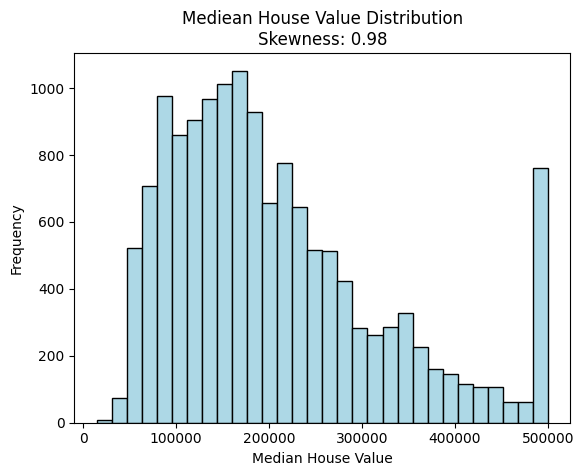

In [12]:
from scipy.stats import skew
plt.hist(1e5 * y_train, bins=30, color='lightblue', edgecolor = 'black')
plt.title(f"Mediean House Value Distribution\nSkewness: {skew(y_train):.2f}")
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### Model fitting and prediction
Let's fit a random forest regression model to the data and use it to make median house price predicions.
Use the default parameters, which includes using 100 base estimators, or regression trees.


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(x_train,y_train)

# predict the test values
y_test_pred = rf_regressor.predict(x_test) 

### Estimate out-of-sample MAE, MSE, RMSE, and R²


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [15]:
mae = mean_absolute_error(y_test,y_test_pred)
mse = mean_squared_error(y_test,y_test_pred)
rmse = root_mean_squared_error(y_test,y_test_pred)
r2 = r2_score(y_test,y_test_pred)

In [17]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.3322
MSE: 0.2564
RMSE: 0.5063
R2 Score: 0.8047
